In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
import numpy as np

data = []
labels = []

dataset_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

for label, emotion in enumerate(sorted(os.listdir(dataset_path))):

    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):

        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels:", np.unique(labels))

Data Shape: (981, 48, 48)
Labels: [0 1 2 3 4 5 6]


In [3]:
from skimage.feature import hog

X_hog = []

for img in data:

    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(feature)

X_hog = np.array(X_hog)

print("HOG Shape:", X_hog.shape)

HOG Shape: (981, 900)


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

2026-06-30 05:54:59.068591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782798899.289960      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782798899.353432      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782798899.883474      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782798899.883516      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782798899.883520      16 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def extract_mobilenet_features(images):

    features = []

    for img in images:

        img = cv2.resize(img,(224,224))

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = preprocess_input(img)

        img = np.expand_dims(img, axis=0)

        feat = mobilenet.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

X_mobile = extract_mobilenet_features(data)

print(X_mobile.shape)

(981, 1280)


In [6]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

def extract_vgg_features(images):

    features = []

    for img in images:

        img = cv2.resize(img,(224,224))

        img = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        img = vgg_preprocess(img)

        img = np.expand_dims(img, axis=0)

        feat = vgg.predict(
            img,
            verbose=0
        )

        features.append(
            feat.flatten()
        )

    return np.array(features)

X_vgg = extract_vgg_features(data)

print(X_vgg.shape)

(981, 512)


In [7]:
from sklearn.preprocessing import StandardScaler

hog_scaler = StandardScaler()
mobile_scaler = StandardScaler()
vgg_scaler = StandardScaler()

X_hog_scaled = hog_scaler.fit_transform(X_hog)

X_mobile_scaled = mobile_scaler.fit_transform(X_mobile)

X_vgg_scaled = vgg_scaler.fit_transform(X_vgg)

In [8]:
weight_configs = [

    (0.34,0.33,0.33),

    (0.60,0.30,0.10),

    (0.70,0.20,0.10),

    (0.50,0.40,0.10),

    (0.35,0.35,0.30)

]

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
import pandas as pd

results = []

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for hog_w, mob_w, vgg_w in weight_configs:

    print("\n")
    print("="*50)
    print(
        f"Weights = "
        f"{hog_w}, "
        f"{mob_w}, "
        f"{vgg_w}"
    )

    X_fusion = np.concatenate([

        X_hog_scaled * hog_w,

        X_mobile_scaled * mob_w,

        X_vgg_scaled * vgg_w

    ], axis=1)

    model = Pipeline([

        ('svm',
         SVC(
             kernel='linear',
             probability=True
         ))

    ])

    y_probs = cross_val_predict(

        model,

        X_fusion,

        labels,

        cv=cv,

        method='predict_proba'

    )

    y_pred = np.argmax(
        y_probs,
        axis=1
    )

    confidence = np.max(
        y_probs,
        axis=1
    )

    overall_acc = accuracy_score(
        labels,
        y_pred
    )

    accepted = confidence >= 0.6

    filtered_acc = accuracy_score(

        labels[accepted],

        y_pred[accepted]

    )

    results.append([

        f"{hog_w},{mob_w},{vgg_w}",

        round(overall_acc*100,2),

        round(filtered_acc*100,2),

        np.sum(accepted)

    ])

    print(
        "Overall Accuracy:",
        round(overall_acc*100,2)
    )

    print(
        "Filtered Accuracy:",
        round(filtered_acc*100,2)
    )



Weights = 0.34, 0.33, 0.33
Overall Accuracy: 99.9
Filtered Accuracy: 100.0


Weights = 0.6, 0.3, 0.1
Overall Accuracy: 100.0
Filtered Accuracy: 100.0


Weights = 0.7, 0.2, 0.1
Overall Accuracy: 99.9
Filtered Accuracy: 100.0


Weights = 0.5, 0.4, 0.1
Overall Accuracy: 100.0
Filtered Accuracy: 100.0


Weights = 0.35, 0.35, 0.3
Overall Accuracy: 99.9
Filtered Accuracy: 100.0


In [10]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Weights",

        "Overall Accuracy",

        "Filtered Accuracy",

        "Accepted Samples"

    ]

)

results_df

,Weights,Overall Accuracy,Filtered Accuracy,Accepted Samples
0,"0.34,0.33,0.33",99.9,100.0,980
1,"0.6,0.3,0.1",100.0,100.0,980
2,"0.7,0.2,0.1",99.9,100.0,980
3,"0.5,0.4,0.1",100.0,100.0,980
4,"0.35,0.35,0.3",99.9,100.0,980


In [11]:
best = results_df.loc[
    results_df[
        "Overall Accuracy"
    ].idxmax()
]

print("\nBest Configuration\n")

print(best)


Best Configuration

Weights              0.6,0.3,0.1
Overall Accuracy           100.0
Filtered Accuracy          100.0
Accepted Samples             980
Name: 1, dtype: object


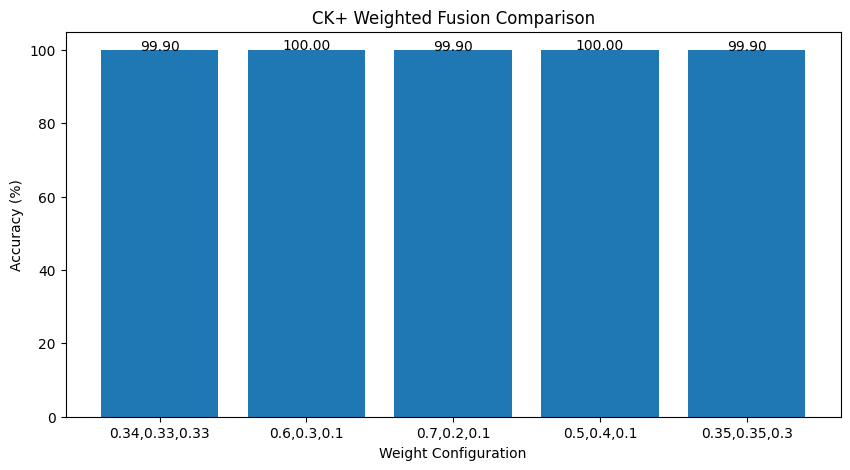

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(

    results_df["Weights"],

    results_df["Overall Accuracy"]

)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height()+0.1,

        f"{bar.get_height():.2f}",

        ha='center'

    )

plt.ylabel("Accuracy (%)")
plt.xlabel("Weight Configuration")
plt.title("CK+ Weighted Fusion Comparison")

plt.show()